# Config acceptance for the v1 generator

An acceptance gate for any config produced by the generator pipeline. Point it at a v1 JSON, get a structured verdict: which gates passed, which failed, whether the config is ready to ship as a puzzle pack.

What this notebook is NOT: a per-config review. It is config-agnostic. Add your own paths to `CONFIGS` below and re-run.

Underlying modules:
- `tests/acceptance.py`: single function `acceptance(path)` returning the verdict dict.
- `tests/config_metrics.py`: R1..R6 deterministic metrics.
- `tests/puzzle_assembly.py`: drives the JS generator on a v1 config.

The two configs in `configs/v1/` shipping with the repo are used here as mock acceptance inputs. They are NOT the subject of this notebook, they are the demo fixtures.

## 1. Setup

Drop any number of v1 configs into `CONFIGS`. Everything below works for N >= 1.

In [1]:
import json, sys
from pathlib import Path
import matplotlib.pyplot as plt

HERE = Path.cwd()
ROOT = HERE.parent if HERE.name == 'tests' else HERE
sys.path.insert(0, str(ROOT / 'tests'))

import config_metrics as cm
import puzzle_assembly as pa
import acceptance as ac

# Replace with paths to your own configs. Anything matching the v1 schema works.
CONFIGS = sorted((ROOT / 'configs' / 'v1').glob('*-v1.json'))
assert CONFIGS, 'no v1 configs found in configs/v1/*-v1.json'
for p in CONFIGS:
    print(p.relative_to(ROOT))

configs/v1/ai-safety-v1.json
configs/v1/reasoning-v1.json


## 2. The acceptance function on one config

`acceptance(path)` returns a dict with these keys:

- `accepted`: bool, true iff every required gate passes
- `metric_gates`: R1..R6 results
- `assembly_gates`: did the puzzle actually assemble in each mode
- `blocked_gates`: required gates that failed
- `metrics`, `assembly`: full underlying outputs for drill-down

Demo on the first config. By default all gates are required, so any single failure -> `accepted=False`.

In [2]:
demo = ac.acceptance(CONFIGS[0], n_seeds_for_variety=100)
print(ac.format_verdict(demo))

# ai-safety-v1  (/sessions/funny-sweet-thompson/mnt/building-connections/configs/v1/ai-safety-v1.json)
  metric gates:
    R1_volume          PASS
    R2_lexical_leak    FAIL
    R3_evidence        FAIL
    R4_mode1           PASS
    R4_mode2           PASS
    R4_mode3           FAIL
    R5_specialty       PASS
  assembly gates:
    normal             PASS
    advanced           PASS
  ACCEPTED: False
  blocked on: ['R2_lexical_leak', 'R3_evidence', 'R4_mode3']


## 3. Batch run across all configs

Same call, looped. Cached as `VERDICTS` for the rest of the notebook.

In [3]:
VERDICTS = [ac.acceptance(p, n_seeds_for_variety=200) for p in CONFIGS]
for v in VERDICTS:
    print(f"{v['config_id']:<30} accepted={v['accepted']!s:<5}  blocked={v['blocked_gates']}")

ai-safety-v1                   accepted=False  blocked=['R2_lexical_leak', 'R3_evidence', 'R4_mode3']
reasoning-v1                   accepted=False  blocked=['R2_lexical_leak', 'R3_evidence', 'R4_mode1', 'R4_mode3']


## 4. Gate matrix across all configs

One row per config, one column per gate. Quick at-a-glance view of where each config stands. If a generator is producing a stream of configs, this is the table you watch.

In [4]:
def badge(b):
    return ' .  ' if b is None else (' OK ' if b else 'FAIL')

gates = list(ac.METRIC_GATES) + [f'assembly_{m}' for m in ac.ASSEMBLY_GATES]
id_w = max(len(v['config_id']) for v in VERDICTS)

header = f"{'config_id':<{id_w}}  " + '  '.join(f'{g:<14}' for g in gates) + '  accepted'
print(header)
print('-' * len(header))
for v in VERDICTS:
    flat = {**v['metric_gates'],
            **{f'assembly_{m}': val for m, val in v['assembly_gates'].items()}}
    row = f"{v['config_id']:<{id_w}}  " + '  '.join(f'{badge(flat.get(g)):<14}' for g in gates)
    row += f"  {'ACCEPTED' if v['accepted'] else 'rejected'}"
    print(row)

config_id     R1_volume       R2_lexical_leak  R3_evidence     R4_mode1        R4_mode2        R4_mode3        R5_specialty    assembly_normal  assembly_advanced  accepted
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------
ai-safety-v1   OK             FAIL            FAIL             OK              OK             FAIL             OK              OK              OK             rejected
reasoning-v1   OK             FAIL            FAIL            FAIL             OK             FAIL             OK              OK              OK             rejected


## 5. Metric drill-down

Same numbers as `metrics.json`, presented per config. Useful when a gate fails and you want to see how badly.

In [5]:
# A compact table: one row per config, one column per key headline number.
rows = []
for v in VERDICTS:
    m = v['metrics']
    if not v['schema_valid']:
        rows.append({'config_id': v['config_id'], 'schema_errors': len(v['schema_errors'])})
        continue
    rows.append({
        'config_id':           v['config_id'],
        'n_terms':             m['R1_volume']['n_terms'],
        'n_axes':              m['R1_volume']['n_axes'],
        'axes_>=4':            m['R1_volume']['axes_with_4plus'],
        'axes_>=20':           m['R1_volume']['axes_with_20plus'],
        'leak_rate':           m['R2_lexical_leak']['lexical_leak_rate'],
        'share_3+sources':     m['R3_evidence']['share_terms_3plus_sources'],
        'mode1_axes':          m['R4_mode_fit']['mode1_eligible_axes'],
        'mode2_pairs':         m['R4_mode_fit']['mode2_cooccurrence_pairs'],
        'mode3_decoys':        m['R4_mode_fit']['mode3_decoy_pool'],
        'log10_capacity':      m['R6_capacity']['log10_puzzle_capacity'],
        'overlap_density':     m['R6_capacity']['axis_overlap_density'],
    })

# Print as fixed-width text so it renders inline without pandas.
cols = list(rows[0].keys())
widths = {c: max(len(c), *(len(str(r.get(c, ''))) for r in rows)) for c in cols}
print('  '.join(f'{c:<{widths[c]}}' for c in cols))
print('-' * (sum(widths.values()) + 2 * (len(cols) - 1)))
for r in rows:
    print('  '.join(f'{str(r.get(c, "")):<{widths[c]}}' for c in cols))

config_id     n_terms  n_axes  axes_>=4  axes_>=20  leak_rate  share_3+sources  mode1_axes  mode2_pairs  mode3_decoys  log10_capacity  overlap_density
------------------------------------------------------------------------------------------------------------------------------------------------------
ai-safety-v1  176      27      27        2          0.193      0.0              14          6            0             15.428          0.7683         
reasoning-v1  138      235     19        1          0.659      0.0              0           1            0             12.124          3.0            


### 5.1. Axis size distribution

Subplot per config. A healthy config has most active axes around the broad-threshold of 20 terms. A long tail of singletons (size 1-3) means lots of axes that the generator can't use for puzzles.

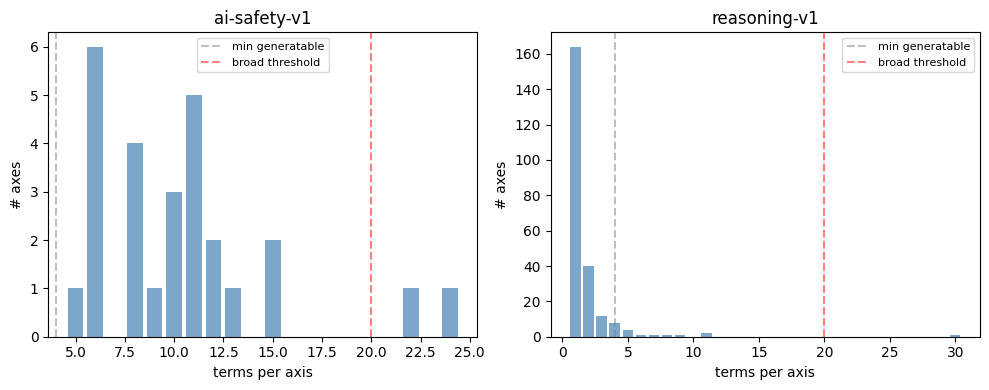

In [6]:
N = len(VERDICTS)
fig, axes = plt.subplots(1, N, figsize=(5 * N, 4), squeeze=False)
for ax, v in zip(axes[0], VERDICTS):
    if not v['schema_valid']:
        ax.text(0.5, 0.5, 'schema invalid', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(v['config_id']); continue
    dist = v['metrics']['R1_volume']['axis_size_distribution']
    xs = sorted(int(k) for k in dist.keys())
    ys = [dist[x] if x in dist else dist[str(x)] for x in xs]
    ax.bar(xs, ys, color='steelblue', alpha=0.7)
    ax.set_title(v['config_id'])
    ax.set_xlabel('terms per axis'); ax.set_ylabel('# axes')
    ax.axvline(4, color='gray', linestyle='--', alpha=0.5, label='min generatable')
    ax.axvline(20, color='red', linestyle='--', alpha=0.5, label='broad threshold')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### 5.2. Capacity vs overlap (R6 bootstrap)

Random subsets of axes give us a scatter of (overlap_density, log10_capacity) points. A monotonic upward slope means overlap is doing real work for puzzle variety in this config. Flat or noisy clouds mean overlap is incidental.

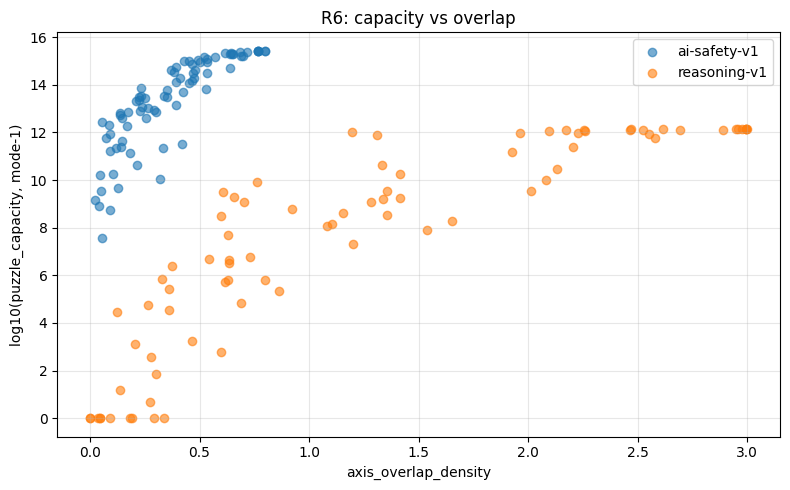

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
for v in VERDICTS:
    if not v['schema_valid']: continue
    cfg = cm.load_config(v['config_path'])
    pts = cm.bootstrap_capacity_overlap(cfg, n_samples=80, seed=1)
    if not pts: continue
    xs, ys = zip(*pts)
    ax.scatter(xs, ys, alpha=0.6, label=v['config_id'])
ax.set_xlabel('axis_overlap_density')
ax.set_ylabel('log10(puzzle_capacity, mode-1)')
ax.set_title('R6: capacity vs overlap')
ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

## 6. Assembly track

Independent of the metric gates: does the JS generator actually produce a valid 16-tile board for this config in each mode? Modes:
- `normal`: 4 categories x 4 terms = 16 tiles.
- `advanced`: 3 categories x 4 terms + 4 decoys = 16 tiles.

Variety counts come from running 200 seeds through the generator and de-duplicating.

In [8]:
print(f"{'config_id':<30} {'mode':<10} {'assembles':<10} {'reprod':<8} {'complete':<10} {'1-to-1':<8} {'variety':<10} {'axes used':<10}")
print('-' * 100)
for v in VERDICTS:
    if not v['assembly']: continue
    for mode, blk in v['assembly']['modes'].items():
        var = blk.get('variety', {})
        print(f"{v['config_id']:<30} {mode:<10} "
              f"{str(blk.get('assembles')):<10} {str(blk.get('reproducible')):<8} "
              f"{str(blk.get('boardComplete')):<10} {str(blk.get('oneConceptOneCategory')):<8} "
              f"{str(var.get('distinct_content','-')):<10} {str(var.get('categories_ever_used','-')):<10}")

config_id                      mode       assembles  reprod   complete   1-to-1   variety    axes used 
----------------------------------------------------------------------------------------------------
ai-safety-v1                   normal     True       True     True       True     155        27        
ai-safety-v1                   advanced   True       True     True       True     155        27        
reasoning-v1                   normal     True       True     True       True     155        19        
reasoning-v1                   advanced   True       True     True       True     155        19        


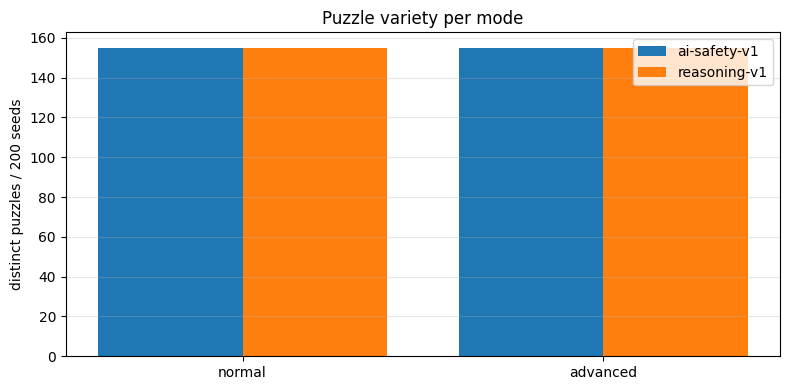

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
modes = list(ac.ASSEMBLY_GATES)
x = list(range(len(modes)))
w = 0.8 / max(len(VERDICTS), 1)
for i, v in enumerate(VERDICTS):
    if not v['assembly']: continue
    vals = [v['assembly']['modes'][m].get('variety', {}).get('distinct_content', 0)
            for m in modes]
    ax.bar([xi + (i - (len(VERDICTS) - 1) / 2) * w for xi in x],
           vals, w, label=v['config_id'])
ax.set_xticks(x); ax.set_xticklabels(modes)
ax.set_ylabel('distinct puzzles / 200 seeds')
ax.set_title('Puzzle variety per mode')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Sample puzzle preview

One generated puzzle per config x mode. Useful spot-check after a generator change: do the categories make sense visually?

In [10]:
for v in VERDICTS:
    if not v['assembly']: continue
    for mode, blk in v['assembly']['modes'].items():
        p = blk.get('puzzle')
        if not p: continue
        print(f"== {v['config_id']} / {mode} ({p['numCategories']} categories) ==")
        for d, c in p['categories'].items():
            print(f"  [{d:7}] {c['name']}")
            for m in c['members']:
                print(f"           - {m}")
        decoys = set(p['board']) - {m for c in p['categories'].values() for m in c['members']}
        if decoys:
            print(f"  [decoys] {sorted(decoys)}")
        print()

== ai-safety-v1 / normal (4 categories) ==
  [easy   ] AI Governance Mechanisms
           - Global ASI Ban
           - Pause
           - Responsible Scaling Policy
           - Transparency
  [medium ] AI Persona & Simulator Theory
           - Three-Layer Model of LLM Psychology
           - LLM Constitution
           - Simulators
           - Simulacra Levels
  [hard   ] Alignment Strategies
           - Interpretability
           - Outer Alignment
           - Eval Cooperativeness
           - Inoculation Prompting
  [harder ] Catastrophic Harm Pathways
           - Value Lock-in
           - Critical Infrastructure Attack
           - Gradual Disempowerment
           - Power Concentration

== ai-safety-v1 / advanced (3 categories) ==
  [easy   ] AI Governance Mechanisms
           - Global ASI Ban
           - Pause
           - Responsible Scaling Policy
           - Transparency
  [medium ] AI Persona & Simulator Theory
           - Three-Layer Model of LLM Psychology
     

## 8. Tuning which gates count

Generator pipelines often want a softer acceptance: skip R3 (evidence) and R4-mode3 (decoys) while those are being populated by a downstream step. `required_gates` controls this. Below is acceptance under a relaxed gate set.

In [11]:
RELAXED = ('R1_volume', 'R2_lexical_leak', 'R4_mode1', 'R4_mode2', 'R5_specialty',
           'assembly_normal', 'assembly_advanced')

for path in CONFIGS:
    v = ac.acceptance(path, n_seeds_for_variety=50, required_gates=RELAXED)
    print(f"{v['config_id']:<30} accepted={v['accepted']!s:<5}  blocked={v['blocked_gates']}")

ai-safety-v1                   accepted=False  blocked=['R2_lexical_leak']


reasoning-v1                   accepted=False  blocked=['R2_lexical_leak', 'R4_mode1']


## 10. How to use this on your own configs

1. Drop the config JSON into `configs/v1/` (or anywhere reachable from this notebook).
2. Either include it in the glob in cell 1, or set `CONFIGS = [Path('...')]` directly.
3. Re-run all cells.
4. From CLI: `python tests/acceptance.py path/to/your-config.json --require R1_volume R5_specialty assembly_normal`.

The acceptance function is the contract. The notebook is a presentation layer; the function is what a CI step should call.